In [1]:
# вычисление оценки
# фрактальной размерности Минковского
# треугольного ковра Серпинского

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# изображение ковра Серпинского
def Serpinsky(L_max):
    # L_max - порядок ковра Серпинского
    # задание рекурсивной функции,
    # прорисовывающей треугольники белого цвета
    # соответствующих размеров

    # задание рекурсивной функции,
    # вычисляющих координаты треугольников
    # соответствующих уровней их визуализацию
    def Simplex(x1, y1, x2, y2, x3, y3, n, L_max):
        # входные переменные:
        # x1, y1 - координаты первой
        #          вершины треугольника
        # x2, y2 - координаты второй
        #          вершины треугольника
        # x3, y3 - координаты третьей
        #          вершины треугольника
        # n - номер текущего порядка
        #     треугольников
        # L_max - порядок треугольного
        #         ковра Серпинского

        if n < L_max:
            # вычисление значений
            # координат вершин треугольников
            # данного уровня
            dx = (x2 - x1) / 2
            dy = (y3 - y1) / 2
            X1_n = x1 + dx
            Y1_n = y1
            X2_n = x1 + dx + dx / 2
            Y2_n = y1 + dy
            X3_n = x1 + dx / 2
            Y3_n = y1 + dy

            # увеличение значения
            # счетчика порядка
            # треугольного ковра Серпинского
            n = n + 1

            # визуализация данного треугольника
            ax.add_patch(
                plt.Polygon(
                    [[X1_n, Y1_n], [X2_n, Y2_n], [X3_n, Y3_n]], facecolor="white"
                )
            )
            # рекурсия
            Simplex(x1, y1, X1_n, Y1_n, X3_n, Y3_n, n, L_max)
            Simplex(X1_n, Y1_n, x2, y2, X2_n, Y2_n, n, L_max)
            Simplex(X3_n, Y3_n, X2_n, Y2_n, x3, y3, n, L_max)

    # задание координат
    # вершин базового треугольника
    x1 = 0
    y1 = 0

    x2 = 1
    y2 = 0

    x3 = 0.5
    y3 = np.sin(np.pi / 3)

    # создание графического окна и
    # сохранение отображаемой в нем
    # информации в переменной F
    # тип переменной F - Figure (800 х 800)
    F = plt.figure(figsize=(8, 8))

    ax = F.add_subplot()

    # отображение базового треугольника черного цвета
    polygon1 = np.array([[x1, y1], [x2, y2], [x3, y3]])
    ax.add_patch(plt.Polygon(polygon1, facecolor="black"))
    plt.axis("equal")
    # отключение нумерации
    # осей графика
    plt.axis("off")

    # вызов рекурсивной функции Simplex
    Simplex(x1, y1, x2, y2, x3, y3, 0, L_max)

    plt.show()

    return F

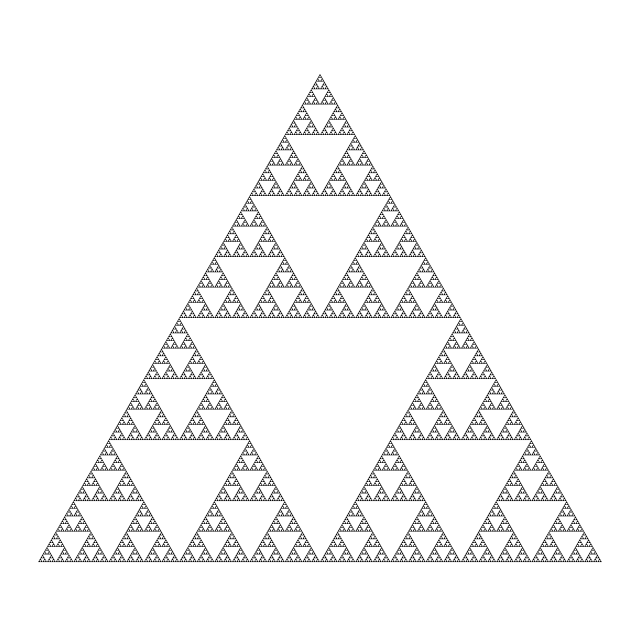

In [3]:
# Ячейка № 3

# визуализация изображения
# треугольного ковра Серпиcкого и
# и его размещение в переменной fig
fig = Serpinsky(8)


In [ ]:
# Ячейка № 4

# размещение изображения,
# ковра Серпинского
# из переменной fig
# в кэш-память
fig.canvas.draw()

# перемещение содержимого из буфера RGBA,
# находящегося в кэш-памяти,
# в 8-битовой кодировке в массив data
data = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)

# преобразование структуры массива data
# в структуру двумерного массива RGBA
data = data.reshape(fig.canvas.get_width_height()[::-1] + (4,))


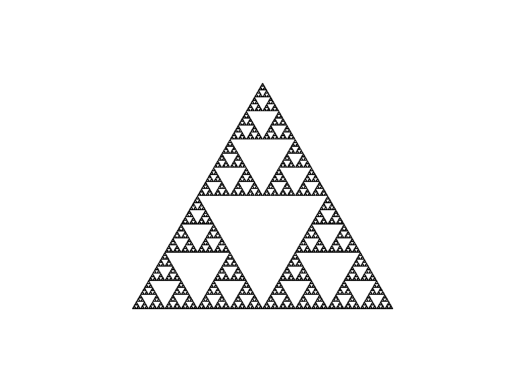

In [ ]:
# Ячейка № 5

# визуализация изображения ковра Серпинского
# после выполнения на его исходным изображением
# следующей последовательности действий:
# 1) копирования изображения в буфер обмена;
# 2) перемещения содержимого кэш-памяти
#    в буфер RGBA в 8-битовой кодировке;
# 3) преобразование структуры массива data
#    в структуру двумерного массива RGBA
data2d = np.uint8(np.all(data[:, :, :3] == 255, axis=2))
plt.axis("equal")
plt.axis("off")
plt.imshow(data2d, cmap="gray")

plt.show()

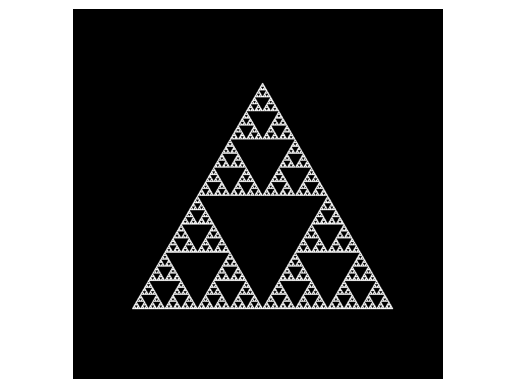

In [6]:
# Ячейка № 6

# инвертирование цвета изображения
# ковра Серпинского
data2d_inv = np.where((data2d == 0) | (data2d == 1), data2d ^ 1, data2d)

# визуализация инвертированного
# изображения ковра Серпинского
plt.axis("equal")
plt.axis("off")
plt.imshow(data2d_inv, cmap="gray")

plt.show()

In [7]:
# Ячейка № 7

# задание функции, возвращающей
# инвертированную бинарную
# матрицу изображения


def Figure2Inv_Bin_Matrix(fig):
    # входная переменная
    # fig -- переменная типа Figure

    # размещение изображения,
    # ковра Серпинского
    # из переменной fig
    # в кэш-память
    fig.canvas.draw()

    # перемещение содержимого из буфера RGBA,
    # находящегося в кэш-памяти,
    # в 8-битовой кодировке в массив data
    data = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)

    # преобразование структуры массива data
    # в структуру двумерного массива RGBA
    data = data.reshape(fig.canvas.get_width_height()[::-1] + (4,))

    # преобразование структуры массива data
    # в структуру двумерного массива RGBA
    data2d = np.uint8(np.all(data[:, :, :3] == 255, axis=2))

    # инвертирование цвета изображения
    # ковра Серпинского
    data2d_inv = np.where((data2d == 0) | (data2d == 1), data2d ^ 1, data2d)

    return data2d_inv


In [8]:
# Ячейка № 8

# задание функции, возвращающей
# оценку фрактальной размерности
# двумерного изображения по Минковскому


def Dim_Minkovsky(fig, L_max):
    # входные переменные:
    # fig - двумерное изображение фрактала
    # L_max - максимальное значение числа
    #         квадратов, покрывающих изображение

    # преобразование двумерного изображения
    # в его инвертированную бинарную матрицу
    M2 = Figure2Inv_Bin_Matrix(fig)

    # вычисление фрактальной размерности
    # двумерного изображения по Минковскому
    Size = M2.shape
    Lx = int(Size[0])
    Ly = int(Size[1])
    N_no_zeros = np.zeros(L_max)
    for L in range(1, L_max + 1):
        Dx = int(Lx / (L + 1))
        Dy = int(Ly / (L + 1))
        tmp = np.zeros([Dy, Dx])
        for j in range(Dy):
            Ny1 = (j - 1) * L + 1
            Ny2 = j * L + 1
            for i in range(Dx):
                Nx1 = (i - 1) * L + 1
                Nx2 = i * L + 1
                tmp = M2[Ny1:Ny2, Nx1:Nx2]
                if np.sum(tmp) > 0:
                    N_no_zeros[L - 1] = N_no_zeros[L - 1] + 1

    # визуализация зависимости
    # логарифма числа квадратов,
    # покрывающих двумерное изображение,
    # от логарифма длины стороны квадрата
    Tmp = np.linspace(2, L_max + 1, L_max)
    Ksi = np.log(Tmp[:])
    Nu = np.log(N_no_zeros[:])
    plt.plot(Ksi[0 : len(Ksi)], Nu[0 : len(Ksi)], "*k", markersize=5)

    # вычисление оценки
    # фрактальной размерности
    s = np.polyfit(Ksi[0 : len(Ksi)], Nu[0 : len(Ksi)], 1)

    # визуализация линейной аппроксимации
    plt.plot(Ksi[0 : len(Ksi)], s[0] * Ksi[0 : len(Ksi)] + s[1], "-k", lw=1)

    plt.grid(True)

    plt.show()

    print("d = ", -s[0])

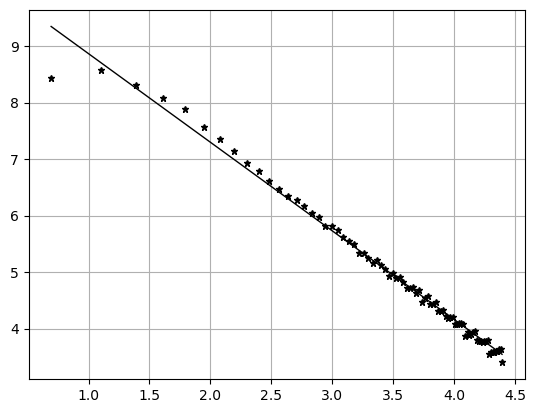

d =  1.5674727251942042
 
Точное значение фрактальной размерности =  1.5849625007211563


In [9]:
# Ячейка № 9

L = 80
Dim_Minkovsky(fig, L)
print(" ")
print("Точное значение фрактальной размерности = ", np.log(3) / np.log(2))

In [10]:
# Ячейка № 10

# задание функции, возвращающей
# значение поточечной оценки фрактальной
# размерности двумерного изображения
def Dim_Points(fig, L_max):
    # входные переменные:
    # fig - двумерное изображение фрактала
    # L_max - максимальное значение числа
    #         квадратов, покрывающих изображение

    # преобразование двумерного изображения
    # в его инвертированную бинарную матрицу
    M2 = Figure2Inv_Bin_Matrix(fig)

    Size = data2d_inv.shape
    Lx = int(Size[0])
    Ly = int(Size[1])
    L_m = int(L_max / 2)
    P = np.zeros([Lx * Ly, L_m])
    N = np.zeros(L_m)
    for i in range(L_m, Ly - L_m):
        for j in range(0, Lx - L_m, L_m):
            if M2[i, j] == 1:
                for L in range(1, L_m + 1):
                    Ny1 = i - L
                    Ny2 = i + L
                    Nx1 = j - L
                    Nx2 = j + L
                    tmp = M2[Ny1:Ny2, Nx1:Nx2]
                    m = np.sum(tmp)
                    if m > 0:
                        P[m, L - 1] = P[m, L - 1] + 1

    M = np.linspace(1, Lx * Ly, Lx * Ly)
    for L in range(L_m):
        N[L] = np.sum(P[:, L] / M[:])
    Tmp = np.linspace(1, L_m, L_m)
    Ksi = np.zeros(L_m)
    Ksi[:] = np.log(2 * Tmp[:] + 1)
    Nu = np.zeros(L_m)
    Nu = np.log(N[:])
    plt.plot(Ksi[0 : len(Ksi)], Nu[0 : len(Ksi)], "*k", markersize=5)
    s = np.polyfit(Ksi[0 : len(Ksi)], Nu[0 : len(Ksi)], 1)
    plt.plot(Ksi[0 : len(Ksi)], s[0] * Ksi[0 : len(Ksi)] + s[1], "-k", lw=1)
    plt.grid(True)
    plt.show()

    print("d = ", -s[0])

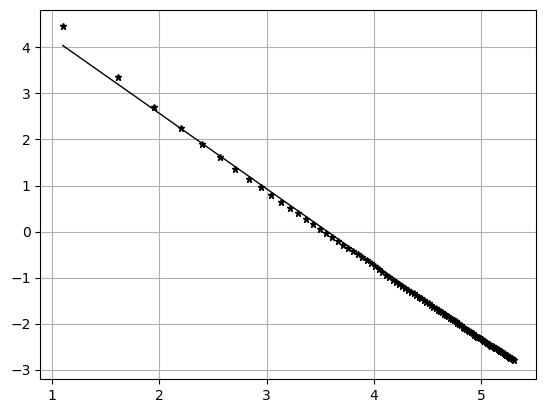

d =  1.638188035488209
Точное значение фрактальной размерности =  1.5849625007211563


In [ ]:
# Ячейка № 11

# вычисление значения
# поточечной фрактальной размерности
L = 200
Dim_Points(fig, L)
print("Точное значение фрактальной размерности = ", np.log(3) / np.log(2))